#### Clasificación segun ICA ajustado

In [4]:
import pandas as pd

# Funciones de normalización
def normalize_ph(ph):
    if 6.5 <= ph <= 8.5:
        return 100
    elif ph < 6.5:
        return max(0, 100 - ((6.5 - ph) / 2.5) * 100)
    else:
        return max(0, 100 - ((ph - 8.5) / 2.5) * 100)

def normalize_od(od):
    if od >= 8:
        return 100
    elif od >= 6:
        return 80 + ((od - 6) / 2) * 20
    elif od >= 4:
        return 50 + ((od - 4) / 2) * 30
    elif od >= 2:
        return 20 + ((od - 2) / 2) * 30
    else:
        return max(0, (od / 2) * 20)

def normalize_ce(ce):
    return max(0, 100 - ((ce - 500) / 1000) * 100) if ce > 500 else 100

def normalize_std(std):
    return max(0, 100 - ((std - 500) / 1000) * 100) if std > 500 else 100

def normalize_sts(sts):
    return max(0, 100 - ((sts - 20) / 80) * 100) if sts > 20 else 100

def normalize_dureza(hardness):
    if 60 <= hardness <= 120:
        return 100
    elif hardness < 60:
        return max(0, 100 - ((60 - hardness) / 60) * 100)
    else:
        return max(0, 100 - ((hardness - 120) / 180) * 100)

def normalize_cloruros(cl):
    return max(0, 100 - ((cl - 250) / 250) * 100) if cl > 250 else 100

def normalize_turbidez(turb):
    if turb <= 5:
        return 100
    elif turb <= 100:
        return max(0, 100 - ((turb - 5) / 95) * 100)
    else:
        return 0

def normalize_nivel(nivel):
    if 150 <= nivel <= 250:
        return 100
    elif nivel < 150:
        return max(0, 100 - ((150 - nivel) / 100) * 100)
    else:
        return max(0, 100 - ((nivel - 250) / 100) * 100)

def normalize_temperatura(temp):
    if 20 <= temp <= 25:
        return 100
    elif 10 <= temp < 20:
        return max(0, 100 - ((20 - temp) / 10) * 50)
    elif 25 < temp <= 35:
        return max(0, 100 - ((temp - 25) / 10) * 50)
    else:
        return 0

# Pesos adaptados del índice NSF-ICA
pesos = {
    "od_norm": 0.2954,
    "ph_norm": 0.2013,
    "ce_norm": 0.1228,
    "std_norm": 0.1071,
    "sts_norm": 0.0540,
    "dureza_norm": 0.0287,
    "cloruros_norm": 0.0334,
    "turbidez_norm": 0.0892,
    "nivel_norm": 0.0473,
    "temperatura_norm": 0.0207
}

df = pd.read_csv("dataset_simulado_2_neuronas_variacional_p6.csv")

# Renombro columnas
df.rename(columns={
    "OD\n(mg/L)": "od",
    "pH": "ph",
    "CE\n(µS/cm)": "ce",
    "STD\n(mg/L)": "std",
    "STS\n(mL sed/L)": "sts",
    "Dureza\n(mg CaCO3/L)": "dureza",
    "Cloruros\n(mg Cl-/L)": "cloruros",
    "Turbidez (NTU)": "turbidez",
    "Nivel (cm)": "nivel",
    "Temperatura de la muestra (°C)": "temperatura"
}, inplace=True)

# Aplico normalización
df["ph_norm"] = df["ph"].apply(normalize_ph)
df["od_norm"] = df["od"].apply(normalize_od)
df["ce_norm"] = df["ce"].apply(normalize_ce)
df["std_norm"] = df["std"].apply(normalize_std)
df["sts_norm"] = df["sts"].apply(normalize_sts)
df["dureza_norm"] = df["dureza"].apply(normalize_dureza)
df["cloruros_norm"] = df["cloruros"].apply(normalize_cloruros)
df["turbidez_norm"] = df["turbidez"].apply(normalize_turbidez)
df["nivel_norm"] = df["nivel"].apply(normalize_nivel)
df["temperatura_norm"] = df["temperatura"].apply(normalize_temperatura)

# Calculo ICA
df["ICA"] = (
    df["od_norm"] * pesos["od_norm"] +
    df["ph_norm"] * pesos["ph_norm"] +
    df["ce_norm"] * pesos["ce_norm"] +
    df["std_norm"] * pesos["std_norm"] +
    df["sts_norm"] * pesos["sts_norm"] +
    df["dureza_norm"] * pesos["dureza_norm"] +
    df["cloruros_norm"] * pesos["cloruros_norm"] +
    df["turbidez_norm"] * pesos["turbidez_norm"] +
    df["nivel_norm"] * pesos["nivel_norm"] +
    df["temperatura_norm"] * pesos["temperatura_norm"]
)

""" # Clasificación del ICA
def clasificar_ica(valor):
    if valor >= 90:
        return "Excelente"
    elif valor >= 70:
        return "Buena"
    elif valor >= 50:
        return "Aceptable"
    elif valor >= 25:
        return "Mala"
    else:
        return "Muy mala" """
    
# Clasificación del ICA
def clasificar_ica(valor):
    if valor >= 95:
        return "Excelente"
    elif valor >= 80:
        return "Buena"
    elif valor >= 65:
        return "Aceptable"
    elif valor >= 45:
        return "Mala"
    else:
        return "Muy mala"

df["clasificación"] = df["ICA"].apply(clasificar_ica)

# Guardo resultado
df.to_csv("resultado_con_ICA.csv", index=False)
print("Archivo guardado como resultado_con_ICA.csv")


Archivo guardado como resultado_con_ICA.csv


#### Histograma del ICA y gráfico de barras con la cantidad de muestras por categoría de calidad del agua

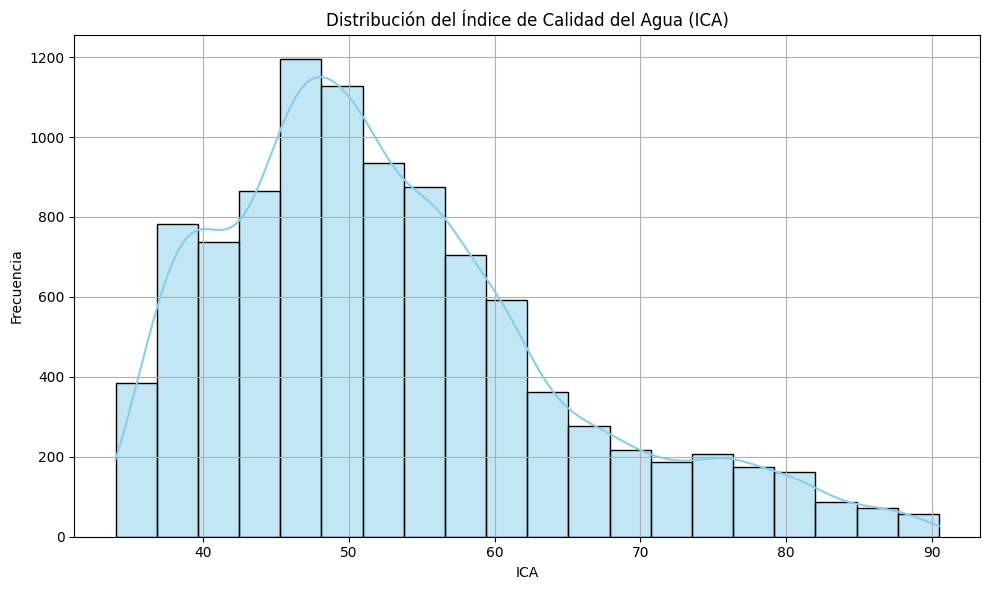

/tmp/ipykernel_12747/1781695250.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="clasificación", order=["Excelente", "Buena", "Aceptable", "Mala", "Muy mala"], palette="viridis")


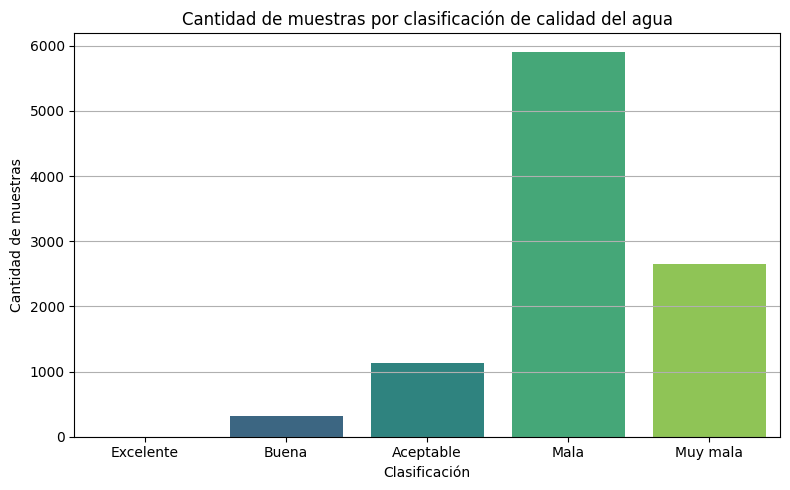

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma del ICA
plt.figure(figsize=(10, 6))
sns.histplot(df["ICA"], bins=20, kde=True, color="skyblue")
plt.title("Distribución del Índice de Calidad del Agua (ICA)")
plt.xlabel("ICA")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de barras por clasificación
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="clasificación", order=["Excelente", "Buena", "Aceptable", "Mala", "Muy mala"], palette="viridis")
plt.title("Cantidad de muestras por clasificación de calidad del agua")
plt.xlabel("Clasificación")
plt.ylabel("Cantidad de muestras")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


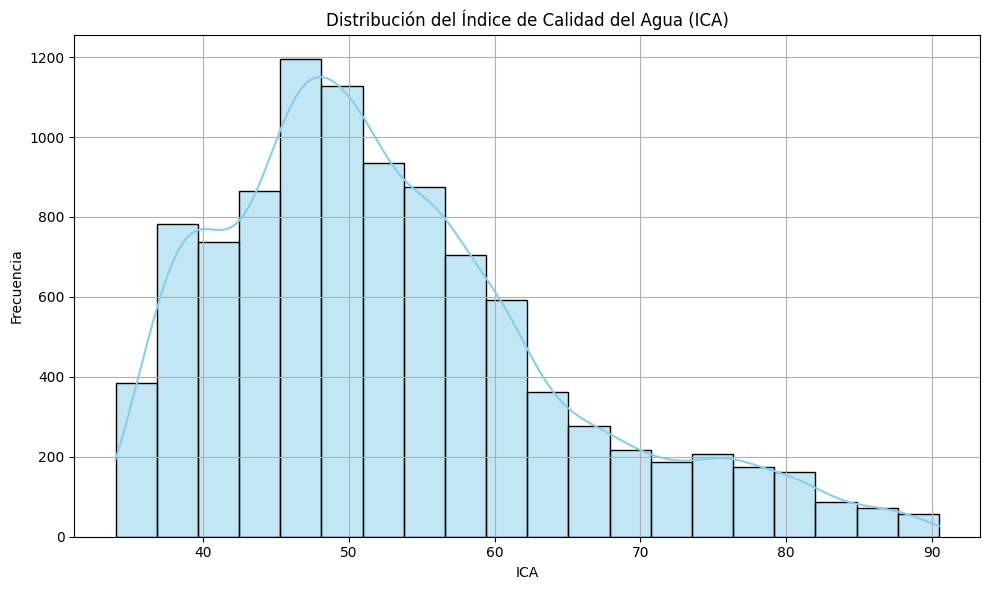

/tmp/ipykernel_12747/2702400990.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clas_counts.index, y=clas_counts.values, palette="viridis")
posx and posy should be finite values
posx and posy should be finite values


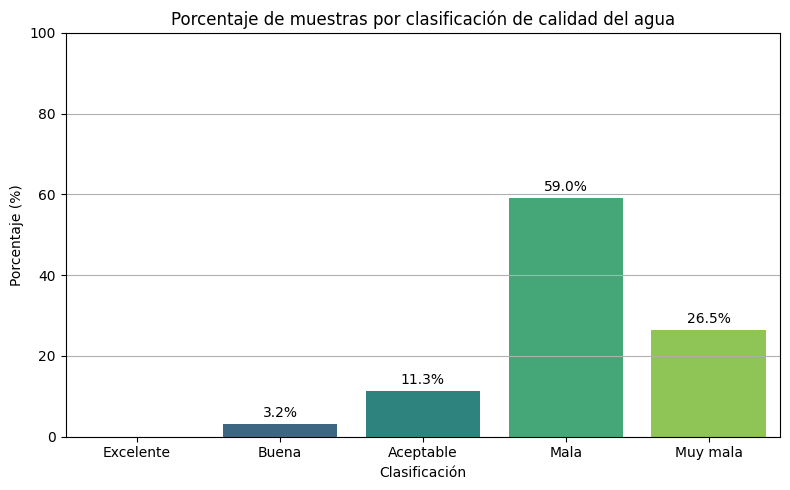

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma del ICA (sin cambios)
plt.figure(figsize=(10, 6))
sns.histplot(df["ICA"], bins=20, kde=True, color="skyblue")
plt.title("Distribución del Índice de Calidad del Agua (ICA)")
plt.xlabel("ICA")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de barras con porcentajes por clasificación
plt.figure(figsize=(8, 5))

# Calculo de proporciones
clas_counts = df["clasificación"].value_counts(normalize=True).reindex(["Excelente", "Buena", "Aceptable", "Mala", "Muy mala"]) * 100

# Creación de gráfico
sns.barplot(x=clas_counts.index, y=clas_counts.values, palette="viridis")

# Etiquetas y título
plt.title("Porcentaje de muestras por clasificación de calidad del agua")
plt.xlabel("Clasificación")
plt.ylabel("Porcentaje (%)")
plt.ylim(0, 100)
plt.grid(axis="y")

# Mostrar porcentaje encima de cada barra
for i, p in enumerate(clas_counts.values):
    plt.text(i, p + 1, f"{p:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


/tmp/ipykernel_12747/880763053.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clas_counts.index, y=clas_counts.values, palette="viridis")
posx and posy should be finite values
posx and posy should be finite values


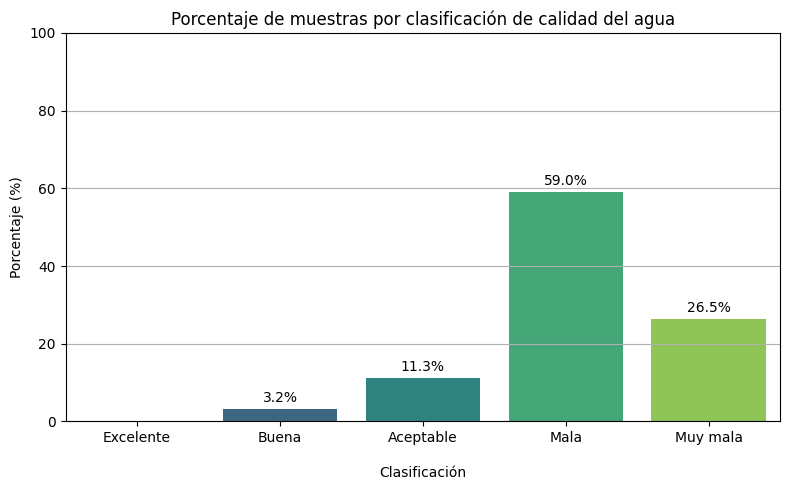

In [8]:
# Gráfico de barras con porcentajes por clasificación
plt.figure(figsize=(8, 5))

# Calculo de proporciones
clas_counts = df["clasificación"].value_counts(normalize=True).reindex(["Excelente", "Buena", "Aceptable", "Mala", "Muy mala"]) * 100

# Creación de gráfico
sns.barplot(x=clas_counts.index, y=clas_counts.values, palette="viridis")

# Etiquetas y título
plt.title("Porcentaje de muestras por clasificación de calidad del agua")
plt.xlabel("Clasificación", labelpad=15)  # Espacio extra entre etiqueta y eje
plt.ylabel("Porcentaje (%)")
plt.ylim(0, 100)
plt.grid(axis="y")

# Mostrar porcentaje encima de cada barra
for i, p in enumerate(clas_counts.values):
    plt.text(i, p + 1, f"{p:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


/tmp/ipykernel_12747/3515425231.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clas_counts.index, y=clas_counts.values, palette="viridis")
posx and posy should be finite values
posx and posy should be finite values


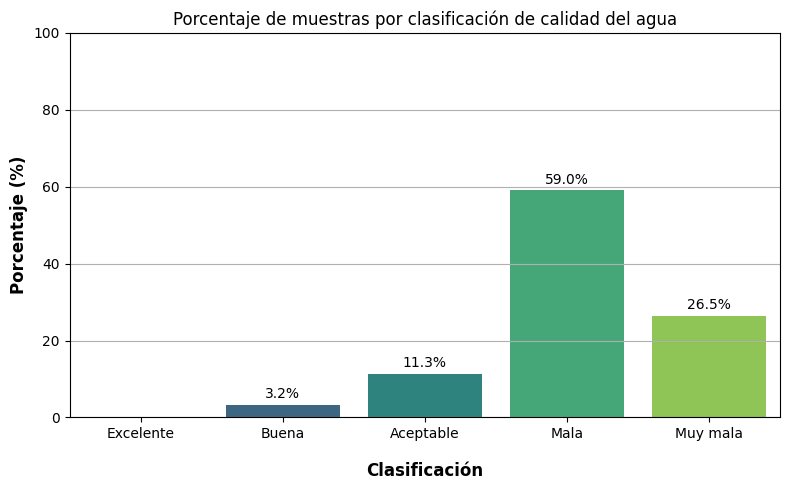

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de barras con porcentajes por clasificación
plt.figure(figsize=(8, 5))

# Calculo de proporciones
clas_counts = df["clasificación"].value_counts(normalize=True).reindex(["Excelente", "Buena", "Aceptable", "Mala", "Muy mala"]) * 100

# Creación gráfico
sns.barplot(x=clas_counts.index, y=clas_counts.values, palette="viridis")

# Título y etiquetas con estilo
plt.title("Porcentaje de muestras por clasificación de calidad del agua")
plt.xlabel("Clasificación", labelpad=15, fontsize=12, fontweight='bold')
plt.ylabel("Porcentaje (%)", fontsize=12, fontweight='bold')
plt.ylim(0, 100)
plt.grid(axis="y")

# Mostrar porcentaje encima de cada barra
for i, p in enumerate(clas_counts.values):
    plt.text(i, p + 1, f"{p:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


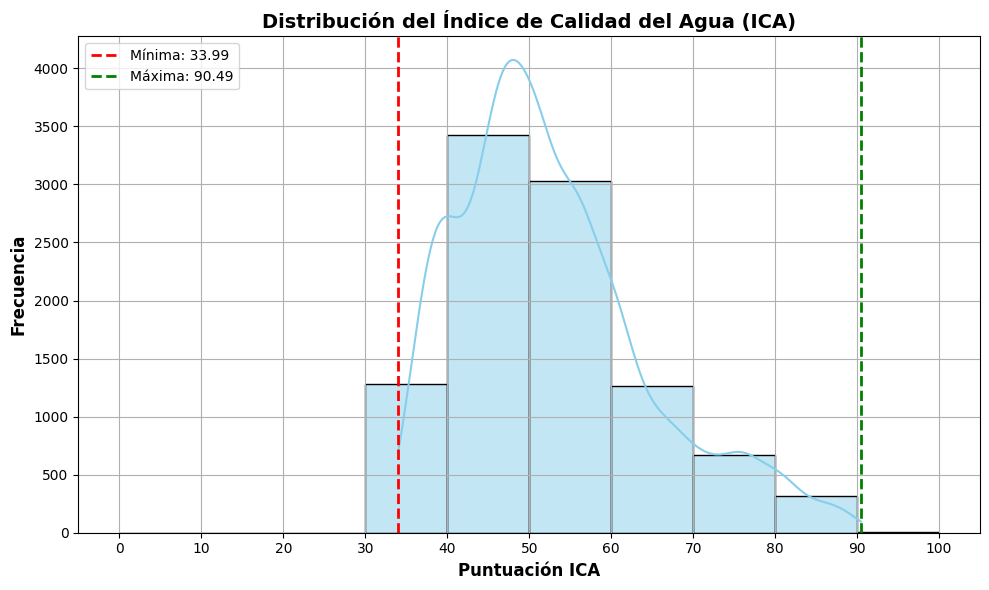

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df["ICA"], bins=range(0, 101, 10), kde=True, color="skyblue")

# Líneas verticales para la puntuación mínima y máxima
min_ica = df["ICA"].min()
max_ica = df["ICA"].max()
plt.axvline(min_ica, color='red', linestyle='--', linewidth=2, label=f"Mínima: {min_ica:.2f}")
plt.axvline(max_ica, color='green', linestyle='--', linewidth=2, label=f"Máxima: {max_ica:.2f}")

# Títulos y etiquetas
plt.title("Distribución del Índice de Calidad del Agua (ICA)", fontsize=14, fontweight='bold')
plt.xlabel("Puntuación ICA", fontsize=12, fontweight='bold')
plt.ylabel("Frecuencia", fontsize=12, fontweight='bold')
plt.xticks(range(0, 101, 10))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


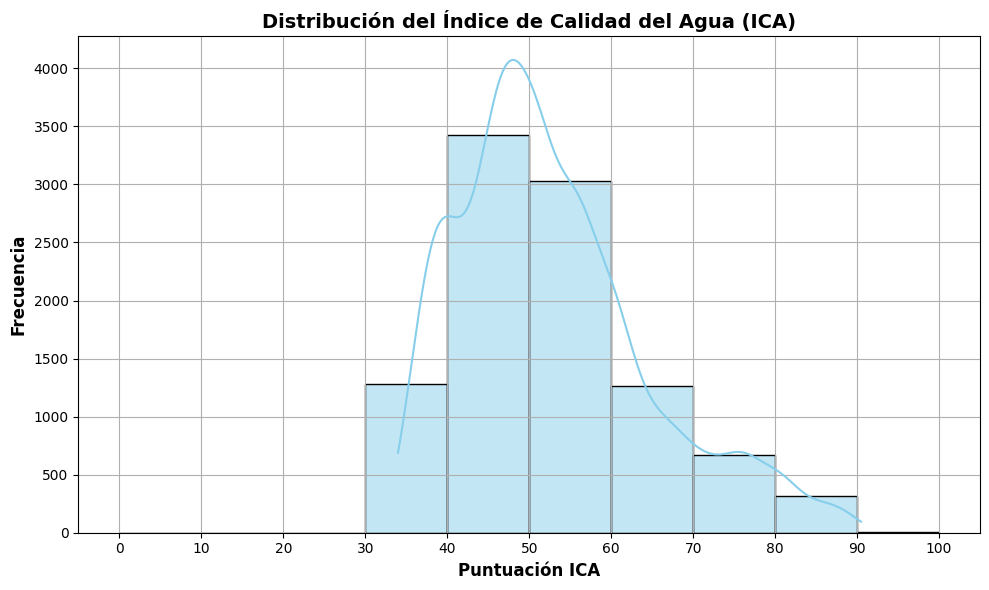

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df["ICA"], bins=range(0, 101, 10), kde=True, color="skyblue")

plt.title("Distribución del Índice de Calidad del Agua (ICA)", fontsize=14, fontweight='bold')
plt.xlabel("Puntuación ICA", fontsize=12, fontweight='bold')
plt.ylabel("Frecuencia", fontsize=12, fontweight='bold')
plt.xticks(range(0, 101, 10))
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
min_ica = df["ICA"].min()
max_ica = df["ICA"].max()
print(f"Puntuación mínima: {min_ica:.2f}")
print(f"Puntuación máxima: {max_ica:.2f}")


Puntuación mínima: 33.99
Puntuación máxima: 90.49
